# N 皇后 benchmark 結果分析：三種啟發式各自怎麼失敗

這本 notebook 讀 `results/benchmark.csv`（360 次求解，3 演算法 × 8 個 N × 20 個 seed），
問的問題只有一個：**失敗的時候，到底是什麼用完了？**

README 已經給了成功率、中位求解時間與三條收斂曲線，並用文字描述了三種失敗模式。
這裡不重複那些結論，而是把它們拆成可以量化查核的問題，並且回答 README 迴避掉的一句話——
「模擬退火在 20→24→32 的 95%→70%→85% 起伏屬取樣噪音，讀趨勢即可」——
噪音有多大，這裡算給你看。

資料與圖表皆不需網路、不需重跑實驗，`results/benchmark.csv` 已納入版控。


## 設定與載入


In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import NullFormatter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# 沿用 experiments/make_charts.py 的配色與字型，讓 notebook 的圖與 README 的圖同一套視覺。
# 不直接 import 那支腳本：它在模組層呼叫 matplotlib.use("Agg")，會關掉 notebook 的內嵌顯示。
ALGOS = ["hill_climbing", "simulated_annealing", "genetic_algorithm"]
COLORS = {"hill_climbing": "#2a78d6", "simulated_annealing": "#eb6834",
          "genetic_algorithm": "#1baf7a"}
LABELS = {"hill_climbing": "爬山演算法", "simulated_annealing": "模擬退火",
          "genetic_algorithm": "基因演算法"}
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Microsoft JhengHei", "Segoe UI", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": AXIS,
    "font.size": 11,
})


def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


df = pd.read_csv(ROOT / "results" / "benchmark.csv")
print(f"{len(df)} 列 × {df.shape[1]} 欄")
df.head(3)


360 列 × 8 欄


,algorithm,n,seed,solved,conflicts,iterations,elapsed,timed_out
0,hill_climbing,8,0,1,0,3,0.0009,0
1,hill_climbing,8,1,1,0,3,0.0010,0
2,hill_climbing,8,2,1,0,11,0.0046,0


## Q1 — 這份資料涵蓋了什麼，格線是完整的嗎？

分析之前先確認實驗網格沒有缺格。README 說每格重複 20 次、seed 0 到 19，
爬山與基因跑 5 個 N、模擬退火跑 8 個。


In [2]:
grid = (df.groupby(["algorithm", "n"])
          .agg(次數=("seed", "size"), 成功=("solved", "sum"), 逾時=("timed_out", "sum"))
          .reset_index())
grid["成功率"] = (grid["成功"] / grid["次數"] * 100).round(0).astype(int).astype(str) + "%"

print("每格次數是否一律 20：", set(grid["次數"]) == {20})
print("seed 是否一律 0–19：",
      all(sorted(g["seed"]) == list(range(20)) for _, g in df.groupby(["algorithm", "n"])))
print("N 的涵蓋：")
for a in ALGOS:
    print(f"  {LABELS[a]:6s} {sorted(int(v) for v in df[df.algorithm == a]['n'].unique())}")
grid


每格次數是否一律 20： True
seed 是否一律 0–19： True
N 的涵蓋：
  爬山演算法  [8, 16, 20, 24, 32]
  模擬退火   [8, 16, 20, 24, 32, 50, 64, 100]
  基因演算法  [8, 16, 20, 24, 32]


,algorithm,n,次數,成功,逾時,成功率
0,genetic_algorithm,8,20,20,0,100%
1,genetic_algorithm,16,20,14,6,70%
2,genetic_algorithm,20,20,16,4,80%
3,genetic_algorithm,24,20,12,8,60%
4,genetic_algorithm,32,20,4,16,20%
5,hill_climbing,8,20,20,0,100%
6,hill_climbing,16,20,20,0,100%
7,hill_climbing,20,20,20,0,100%
8,hill_climbing,24,20,10,10,50%
9,hill_climbing,32,20,2,18,10%


格線完整：18 格 × 20 次 = 360 列，seed 一個不缺。與 README「實驗設計」表格一致。

已經可以看出一件 README 的成功率圖看不到的事：**逾時欄的分佈很不對稱**。
模擬退火整欄是 0，爬山與基因卻在 N 變大時整格整格地逾時。下一題就從這裡切進去。


## Q2 — 失敗的成因能不能一刀切開？

`timed_out` 欄記錄的是「因為超過 60 秒預算而中止」。
失敗（`solved == 0`）可以分成兩種：**時間用完**與**時間還夠但演算法自己停了**。


In [3]:
fail = df[df.solved == 0]
tab = (fail.assign(結果=fail.timed_out.map({1: "逾時", 0: "非逾時"}))
           .pivot_table(index="algorithm", columns="結果", values="seed",
                        aggfunc="size", fill_value=0))
tab.index = [LABELS[a] for a in tab.index]
tab["失敗總數"] = tab.sum(axis=1)
tab["逾時佔比"] = (tab.get("逾時", 0) / tab["失敗總數"] * 100).round(1).astype(str) + "%"
tab


結果,逾時,非逾時,失敗總數,逾時佔比
基因演算法,34,0,34,100.0%
爬山演算法,28,0,28,100.0%
模擬退火,0,60,60,0.0%


**這一刀切得比預期乾淨：**

- 爬山演算法 28 次失敗，**28 次都是逾時**
- 基因演算法 34 次失敗，**34 次都是逾時**
- 模擬退火 60 次失敗，**一次逾時都沒有**

也就是說「失敗成因」在這份資料裡完全由演算法決定，沒有任何混合案例。
爬山與基因輸給的是**時鐘**；模擬退火輸給的是**別的東西**——Q4 會找出是什麼。


## Q3 — 「逾時」對爬山和基因是同一件事嗎？

兩者都是 100% 逾時，但逾時的當下離解有多遠，是完全不同的問題。
看失敗案例中止時的殘餘衝突數。


,失敗次數,最小,中位,最大,平均,卡在1個衝突的比例
基因演算法,34,1,1.0,2,1.15,85.3
爬山演算法,28,2,8.5,26,9.89,0.0
模擬退火,60,1,1.0,6,1.93,55.0


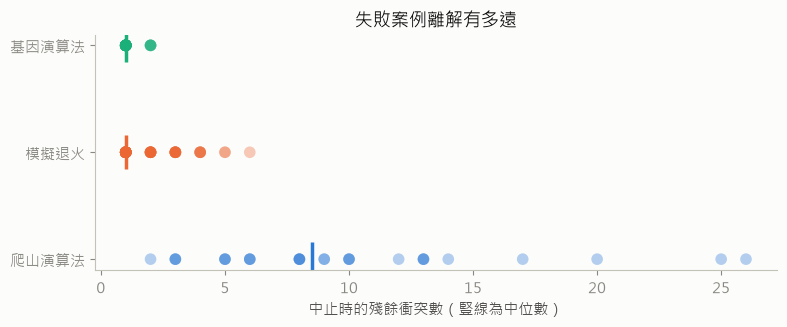

In [4]:
stat = (fail.groupby("algorithm")["conflicts"]
            .agg(失敗次數="size", 最小="min", 中位="median", 最大="max", 平均="mean")
            .round(2))
stat["卡在1個衝突的比例"] = (fail[fail.conflicts == 1].groupby("algorithm").size()
                       .reindex(stat.index, fill_value=0) / stat["失敗次數"] * 100).round(1)
stat.index = [LABELS[a] for a in stat.index]
display(stat)

fig, ax = plt.subplots(figsize=(8, 3.4))
for i, a in enumerate(ALGOS):
    v = fail[fail.algorithm == a]["conflicts"]
    if len(v):
        ax.scatter(v, [i] * len(v) + pd.Series(range(len(v))).mul(0).values,
                   alpha=0.35, s=70, color=COLORS[a], edgecolors="none")
        ax.scatter([v.median()], [i], marker="|", s=600, color=COLORS[a], linewidths=2.5)
ax.set_yticks(range(len(ALGOS)))
ax.set_yticklabels([LABELS[a] for a in ALGOS])
ax.set_xlabel("中止時的殘餘衝突數（豎線為中位數）")
ax.set_title("失敗案例離解有多遠", color=INK)
style_axes(ax)
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()


**同樣是逾時，兩者的處境相反：**

- **基因演算法**幾乎已經解出來了——85.3% 的失敗卡在剩 1 個衝突，最大值只有 2。
  它輸在每代要對 1,000 個個體重算衝突數，時間被吃在族群規模上，不是在搜索方向上。
- **爬山演算法**還在半路——中位殘餘 8.5 個衝突，最大 26，**沒有任何一次卡在 1**。
  全鄰域掃描是 O(n⁴)，60 秒內走不了幾步，時間是被單步成本吃掉的。

這個對比是 README 那句「不是差一步」的量化版本：
爬山的失敗分佈與基因的失敗分佈**沒有重疊**（爬山最小 2，基因最大 2，只在邊界擦過）。


## Q4 — 模擬退火撞到的是什麼牆？

它一次都沒逾時，卻在 N 變大時全面失敗。`iterations` 欄記錄降溫步數，
如果失敗是因為步數預算用完，那應該看到一個天花板。


iterations 的上限：13557 步


,最小,中位,最大,撞頂比例(%)
n,,,,
8,129,449.5,2501,0.0
16,791,3437.5,11505,0.0
20,513,3306.5,13557,5.0
24,913,6271.5,13557,30.0
32,2462,7931.5,13557,15.0
50,6756,13557.0,13557,65.0
64,7065,13557.0,13557,85.0
100,13557,13557.0,13557,100.0


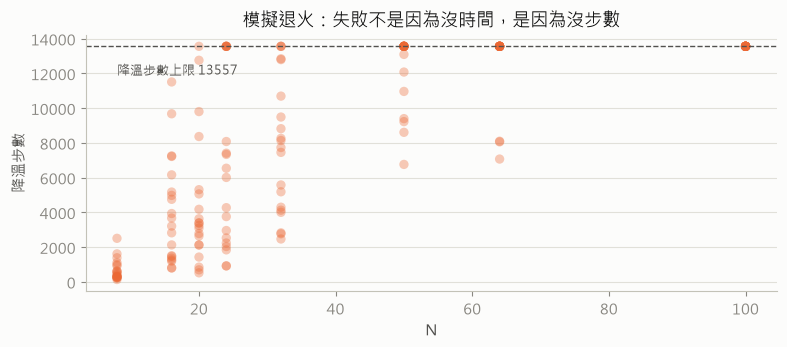

In [5]:
sa = df[df.algorithm == "simulated_annealing"]
it = sa.groupby("n")["iterations"].agg(最小="min", 中位="median", 最大="max")
ceiling = int(sa["iterations"].max())
it["撞頂比例(%)"] = (sa[sa.iterations == ceiling].groupby("n").size()
                   .reindex(it.index, fill_value=0) / 20 * 100).round(0)
print(f"iterations 的上限：{ceiling} 步")
display(it)

fig, ax = plt.subplots(figsize=(8, 3.6))
for n, g in sa.groupby("n"):
    ax.scatter([n] * len(g), g["iterations"], alpha=0.35, s=45,
               color=COLORS["simulated_annealing"], edgecolors="none")
ax.axhline(ceiling, color=INK_2, linewidth=1, linestyle="--")
ax.annotate(f"降溫步數上限 {ceiling}", xy=(8, ceiling), xytext=(8, ceiling * 0.88),
            color=INK_2, fontsize=9)
ax.set_xlabel("N")
ax.set_ylabel("降溫步數")
ax.set_title("模擬退火：失敗不是因為沒時間，是因為沒步數", color=INK)
style_axes(ax)
plt.tight_layout()
plt.show()


天花板是 **13,557 步**——這是幾何降溫從 `t_start` 走到終止溫度的固定步數，與 N 無關。

- N ≤ 32：中位步數還在天花板以下，有餘裕
- N = 50、64：中位數已經**貼在天花板上**
- N = 100：最小值 = 中位數 = 最大值 = 13,557，**20 次全部撞頂**

搭配 Q2 的「零逾時」看，模擬退火在 n=100 的處境是：
**時間還剩很多，步數先用完了**。它的預算單位是迭代數而不是秒數，
所以擴大時間預算對它完全無效——要救它得改降溫排程，不是給更多秒數。
這與爬山、基因的瓶頸是**不同種類的**，不能用同一種方式緩解。


## Q5 — 成功率曲線的起伏，哪些是真的？

README 對模擬退火 20→24→32 的 95%→70%→85% 標了註記，說那是取樣噪音。
每格只有 20 次重複，成功率的粒度是 5%。用 Wilson score 區間把不確定性算出來，
看那段起伏在統計上站不站得住。


模擬退火那三格（README 標為取樣噪音的區段）：


,成功率,下界,上界
n,,,
20,95.0,76.4,99.1
24,70.0,48.1,85.5
32,85.0,64.0,94.8


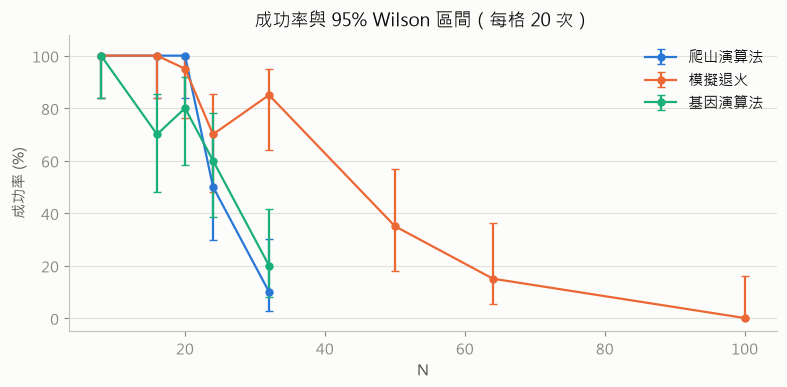

平均區間寬度：26.9 個百分點


In [6]:
def wilson(k, n, z=1.96):
    """Wilson score 區間。比常態近似在極端比例（0% 或 100%）下更不會失控。"""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z ** 2 / n
    centre = p + z ** 2 / (2 * n)
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2))
    return max(0.0, (centre - half) / denom), min(1.0, (centre + half) / denom)


rows = []
for (a, n), g in df.groupby(["algorithm", "n"]):
    k, tot = int(g.solved.sum()), len(g)
    lo, hi = wilson(k, tot)
    rows.append({"algorithm": a, "n": n, "成功率": k / tot * 100,
                 "下界": lo * 100, "上界": hi * 100, "區間寬度": (hi - lo) * 100})
ci = pd.DataFrame(rows)

print("模擬退火那三格（README 標為取樣噪音的區段）：")
display(ci[(ci.algorithm == "simulated_annealing") & (ci.n.isin([20, 24, 32]))]
        .set_index("n")[["成功率", "下界", "上界"]].round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for a in ALGOS:
    s = ci[ci.algorithm == a].sort_values("n")
    # clip：成功率 100% 或 0% 那幾格，區間端點與點估計相等，浮點誤差會讓誤差長度
    # 出現 -1e-14，matplotlib 會直接拒收。
    lo_err = (s["成功率"] - s["下界"]).clip(lower=0)
    hi_err = (s["上界"] - s["成功率"]).clip(lower=0)
    ax.errorbar(s.n, s["成功率"], yerr=[lo_err, hi_err],
                marker="o", markersize=5, capsize=3, linewidth=1.6,
                color=COLORS[a], label=LABELS[a])
ax.set_xlabel("N")
ax.set_ylabel("成功率 (%)")
ax.set_ylim(-5, 108)
ax.set_title("成功率與 95% Wilson 區間（每格 20 次）", color=INK)
ax.legend(frameon=False)
style_axes(ax)
plt.tight_layout()
plt.show()

print(f"平均區間寬度：{ci['區間寬度'].mean():.1f} 個百分點")


**README 的保留是對的，而且可以講得更精確：**

模擬退火 n=20（95%）、n=24（70%）、n=32（85%）三格的 95% 區間彼此**大幅重疊**，
20 次重複撐不起「先降後升」這個敘述——那條線在這一段實務上是平的。

更一般的結論：**平均區間寬度約 27 個百分點**。
以這個樣本數，成功率差距小於 27 個百分點的兩格都不該解讀為真實差異。
所以資料能支持的是「爬山在 n≥24 崩、模擬退火在 n≥50 崩、基因從 n=16 就上不去」這種**量級**判斷，
而不是任何單點的高低。要讓單點可讀，重複次數得從 20 次拉到數百次。


## Q6 — 求解時間的分佈長什麼樣？

README 給的是中位數。中位數看不出分佈形狀，而形狀會決定「這個演算法可不可預測」。


,成功次數,中位,平均,最大,平均/中位
基因演算法,66,10.980,15.964,59.273,1.5
爬山演算法,72,2.151,8.896,59.789,4.1
模擬退火,100,0.107,0.414,6.264,3.9


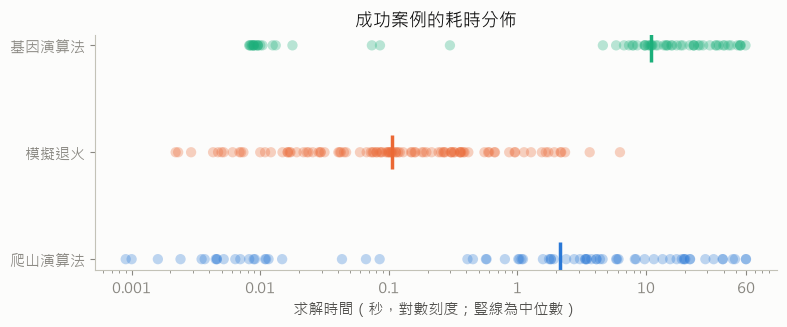

In [7]:
ok = df[df.solved == 1]
shape = ok.groupby("algorithm")["elapsed"].agg(
    成功次數="size", 中位="median", 平均="mean", 最大="max")
shape["平均/中位"] = (shape["平均"] / shape["中位"]).round(1)
shape = shape.round(3)
shape.index = [LABELS[a] for a in shape.index]
display(shape)

fig, ax = plt.subplots(figsize=(8, 3.4))
for i, a in enumerate(ALGOS):
    v = ok[ok.algorithm == a]["elapsed"]
    ax.scatter(v, [i] * len(v), alpha=0.3, s=55, color=COLORS[a], edgecolors="none")
    ax.scatter([v.median()], [i], marker="|", s=600, color=COLORS[a], linewidths=2.5)
ax.set_xscale("log")
# 明確指定刻度：預設的 LogFormatter 會輸出 10^{-2} 這種 mathtext，
# 其中的 U+2212 在中文字型裡沒有對應字符，會畫成空白方塊。
ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 60])
ax.set_xticklabels(["0.001", "0.01", "0.1", "1", "10", "60"])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_yticks(range(len(ALGOS)))
ax.set_yticklabels([LABELS[a] for a in ALGOS])
ax.set_xlabel("求解時間（秒，對數刻度；豎線為中位數）")
ax.set_title("成功案例的耗時分佈", color=INK)
style_axes(ax)
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()


三者都右偏，但程度差很多：

- **爬山演算法**最極端，平均是中位數的 **4.1 倍**，跨了近五個數量級（0.0009 秒到 59.8 秒）。
  隨機重啟讓它的耗時本質上是幾何分佈——多數跑很快，少數要重啟上百次。
  「中位 2.15 秒」對單次求解幾乎沒有預測力。
- **模擬退火**分佈最緊，最大值 6.3 秒。這與 Q4 一致：它的成本由固定步數決定，不由運氣決定。
- **基因演算法**中位就要 11 秒，分佈整體右移——每代成本高，起步就慢。

**可預測性和平均效能是兩回事。** 若要放進有時間預算的系統，
模擬退火的分佈形狀比它的中位數更值得看。


## 小結：這份分析補上了 README 沒說的三件事

| # | 發現 | 為什麼重要 |
|---|---|---|
| 1 | 失敗成因可由 `timed_out` **完全**切開：爬山與基因 100% 逾時，模擬退火 0% 逾時 | 「三種失敗模式」不只是描述，是資料上乾淨可驗證的分界 |
| 2 | 模擬退火撞的是 **13,557 步的降溫天花板**，n=100 時 20 次全撞頂 | 它的瓶頸與時間無關，**加時間預算救不了它**——要救得改降溫排程 |
| 3 | 每格 20 次重複的 95% 區間平均寬 **27 個百分點** | 成功率曲線只能讀量級，不能讀單點；README 對模擬退火那段的保留有了數字支撐 |

另外兩點值得記下來：爬山與基因雖然都是 100% 逾時，
但基因 85% 的失敗卡在剩 1 個衝突、爬山中位還剩 8.5 個且**從未**卡在 1——
同一個「逾時」標籤底下是兩種完全不同的處境。
而爬山的耗時平均是中位的 4.1 倍、跨近四個數量級，
它的中位求解時間對單次求解幾乎沒有預測力。

重跑本 notebook：`jupyter nbconvert --execute --inplace notebooks/eda.ipynb`
（只讀 `results/benchmark.csv`，不需重跑實驗、不需網路）。
